# Kuramoto Oscillators on a Ring

Nearest-neighbor Kuramoto model on a 1D periodic chain. Run all cells, then scroll to the bottom to play with `K`, `N`, and `seed` interactively.

Source: [velvetmonkey/flywheel-universe](https://github.com/velvetmonkey/flywheel-universe)


In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ipywidgets import interact, FloatSlider, IntSlider


In [82]:
def kuramoto(t, theta, omega, K, N=None):
    """RHS of Kuramoto ODE on a ring (nearest-neighbor coupling).
    Vectorized via np.roll: ~10x faster than the index-by-index for-loop
    on the parameter sweep. N is unused (kept for backward-compat signature)."""
    return omega + K * (np.sin(np.roll(theta, -1) - theta) + np.sin(np.roll(theta, 1) - theta))


def order_parameter(theta):
    """Magnitude of the complex order parameter r."""
    z = np.mean(np.exp(1j * theta))
    return np.abs(z)


In [83]:
N = 120
rng_omega = np.random.default_rng(42)
omega = rng_omega.normal(0.0, 0.65, N)
# σ = 0.65 chosen to give moderate disorder relative to the K range [0, 4].
# Mean-field K_c for this distribution: 2σ√(2/π) ≈ 1.037
# (not 1.2 — that value is wrong; see parameter-sweep note).
t_span = (0, 150)


## 1. Order parameter vs coupling strength (single-realisation sweep)

> **Note:** This is a parameter sweep, not a bifurcation diagram. A bifurcation diagram
> requires solution branches, stability analysis, and typically hysteresis sweeps.
> The global order parameter *r* is also structurally insensitive to the dominant
> physics here: twisted states (winding number q ≠ 0) give r ≈ 0 even when the ring
> is strongly locally ordered. A local order parameter or winding-number scan is more
> informative — see cells below.


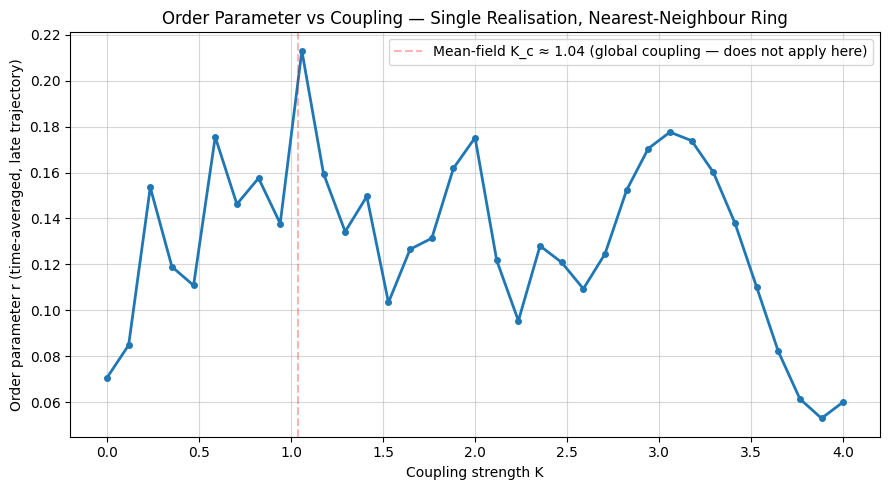

In [84]:
rng_sweep = np.random.default_rng(42)
theta0_sweep = rng_sweep.uniform(0, 2*np.pi, N)  # fixed IC across all K — isolates coupling dependence
K_values = np.linspace(0.0, 4.0, 35)
r_final = []
T_EVAL = np.linspace(t_span[0], t_span[1], 1500)  # uniform grid — required for valid time averages
for K in K_values:
    theta0 = theta0_sweep.copy()
    sol = solve_ivp(kuramoto, t_span, theta0, args=(omega, K, N), method='DOP853', t_eval=T_EVAL, rtol=1e-7, atol=1e-9)
    if not sol.success:
        raise RuntimeError(f"K={K:.2f}: {sol.message}")
    # Time-average r over the final 20% (uniform grid, so this is a true time average)
    idx = int(0.8 * len(T_EVAL))
    r_late = np.mean([order_parameter(sol.y[:, j]) for j in range(idx, len(T_EVAL))])
    r_final.append(r_late)

plt.figure(figsize=(9, 5))
plt.plot(K_values, r_final, 'o-', linewidth=2, markersize=4)
# Correct mean-field K_c for Gaussian g(ω) with σ=0.65: 2σ√(2/π) ≈ 1.037
# Shown for reference only — mean-field K_c has no direct meaning for
# nearest-neighbour coupling (different 1/N scaling), and r is a poor
# diagnostic for this geometry. See winding-number cell.
plt.axvline(x=1.037, color='red', linestyle='--', alpha=0.3,
            label='Mean-field K_c ≈ 1.04 (global coupling — does not apply here)')
plt.xlabel('Coupling strength K')
plt.ylabel('Order parameter r (time-averaged, late trajectory)')
plt.title('Order Parameter vs Coupling — Single Realisation, Nearest-Neighbour Ring')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()


## 2. Simulation at K = 2.5 — local order, winding diagnostics, and phase-slip regime

In [85]:
K_sim = 2.5  # local-order / winding-diagnostic regime
rng_demo = np.random.default_rng(43)
theta0 = rng_demo.uniform(0, 2*np.pi, N)
sol = solve_ivp(kuramoto, t_span, theta0, args=(omega, K_sim, N),
                method='DOP853', dense_output=True, rtol=1e-7, atol=1e-9)
if not sol.success:
    raise RuntimeError(sol.message)
t_plot = np.linspace(t_span[0], t_span[1], 1500)  # uniform grid for valid time averages

R_real, R_imag, r_time = [], [], []
for t in t_plot:
    z = np.mean(np.exp(1j * sol.sol(t)))
    R_real.append(z.real)
    R_imag.append(z.imag)
    r_time.append(np.abs(z))
R_real = np.array(R_real)
R_imag = np.array(R_imag)


### A. Time evolution of the order parameter

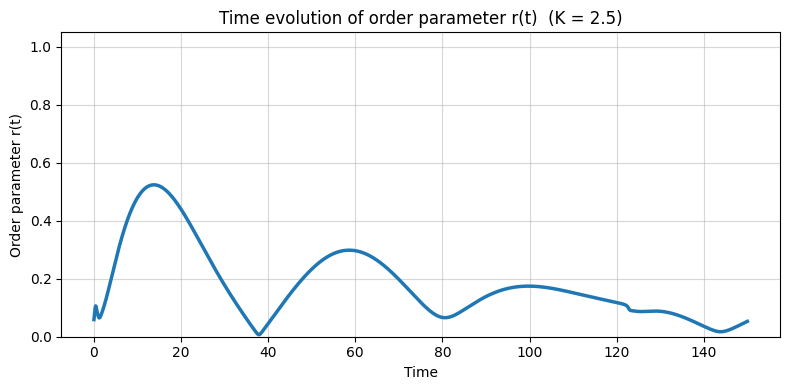

In [86]:
plt.figure(figsize=(8, 4))
plt.plot(t_plot, r_time, linewidth=2.5)
plt.xlabel('Time')
plt.ylabel('Order parameter r(t)')
plt.title(f'Time evolution of order parameter r(t)  (K = {K_sim})')
plt.grid(True, alpha=0.5)
plt.ylim(0, 1.05)
plt.tight_layout()


### B. Phase portrait in the complex plane

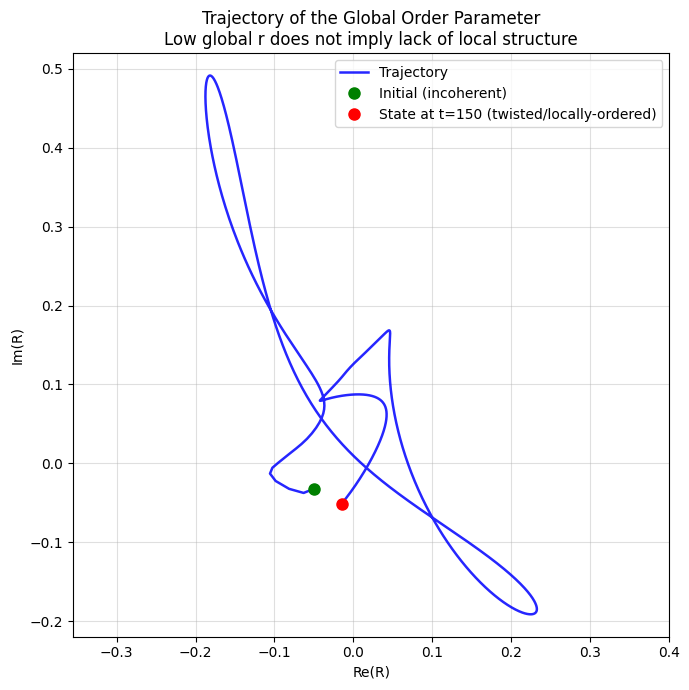

In [87]:
plt.figure(figsize=(7, 7))
plt.plot(R_real, R_imag, 'b-', linewidth=1.8, alpha=0.85, label='Trajectory')
plt.plot(R_real[0], R_imag[0], 'go', markersize=8, label='Initial (incoherent)')
plt.plot(R_real[-1], R_imag[-1], 'ro', markersize=8, label='State at t=150 (twisted/locally-ordered)')
plt.xlabel('Re(R)')
plt.ylabel('Im(R)')
plt.title('Trajectory of the Global Order Parameter\nLow global r does not imply lack of local structure')
plt.axis('equal')
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()


### C. Phase evolution heatmap

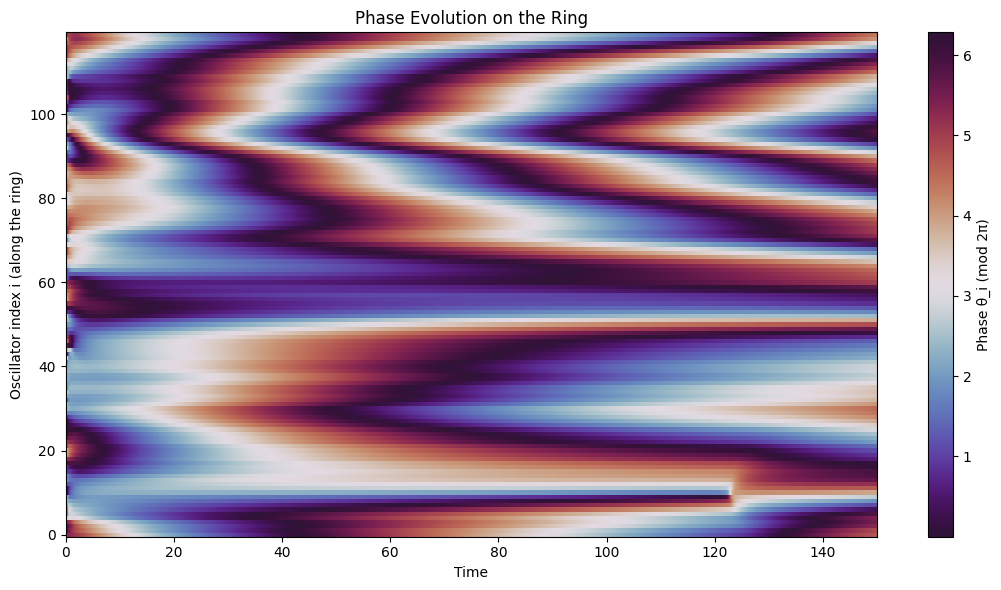

In [88]:
theta_sol = np.array([sol.sol(t) for t in t_plot]).T
phases_wrapped = theta_sol % (2 * np.pi)

plt.figure(figsize=(11, 6))
plt.pcolormesh(t_plot, np.arange(N), phases_wrapped, cmap='twilight_shifted', shading='auto')
plt.colorbar(label='Phase θ_i (mod 2π)')
plt.xlabel('Time')
plt.ylabel('Oscillator index i (along the ring)')
plt.title('Phase Evolution on the Ring')
plt.tight_layout()


### D. Initial vs final ring configuration

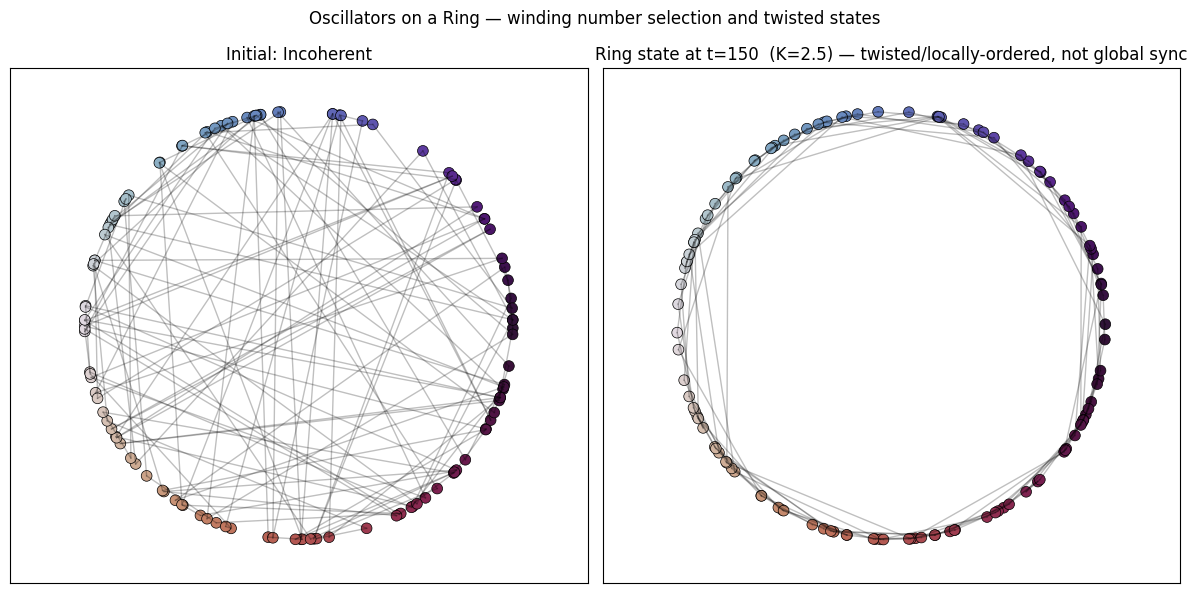

In [89]:
def plot_ring(theta, title, ax):
    phase = theta % (2 * np.pi)
    x = np.cos(phase)
    y = np.sin(phase)
    ax.scatter(x, y, c=phase, cmap='twilight_shifted', vmin=0, vmax=2*np.pi, s=60, edgecolor='black', linewidth=0.5)
    for i in range(len(theta)):
        ax.plot([x[i], x[(i+1) % len(theta)]], [y[i], y[(i+1) % len(theta)]], 'k-', alpha=0.25, linewidth=1)
    ax.set_title(title)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plot_ring(theta0, 'Initial: Incoherent', ax1)
plot_ring(sol.sol(t_plot[-1]), f'Ring state at t={t_plot[-1]:.0f}  (K={K_sim}) — twisted/locally-ordered, not global sync', ax2)
plt.suptitle('Oscillators on a Ring — winding number selection and twisted states')
plt.tight_layout()


### E. Winding number q(t)

Final winding number: q = -1
Detected q changes on sampled grid: 7
Detected single-step q changes (|Δq|=1): 6
Note: these are sampled-grid detections, not a rigorous phase-slip count.


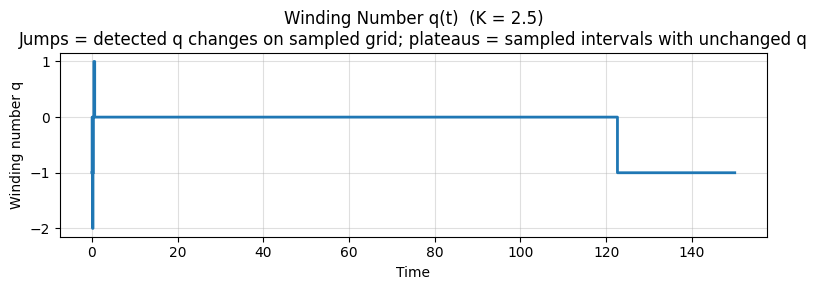

In [90]:
def winding_number(theta):
    """Principal-branch winding diagnostic for a discrete phase ring.

    q = net phase winding around the ring (integer).
    q is NOT conserved here — phase slips change it.
    q = 0 does not imply synchrony. q != 0 does not prove a stable sector.
    Meaningful only when the configuration is locally smooth and
    the trajectory stays within one winding sector between slip events.
    """
    diffs = np.diff(theta, append=theta[0])
    # Wrap each difference into [-π, π)
    diffs_wrapped = (diffs + np.pi) % (2 * np.pi) - np.pi
    return int(np.round(np.sum(diffs_wrapped) / (2 * np.pi)))

q_time = [winding_number(sol.sol(t)) for t in t_plot]

plt.figure(figsize=(8, 3))
plt.step(t_plot, q_time, where='mid', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Winding number q')
plt.title(f'Winding Number q(t)  (K = {K_sim})\nJumps = detected q changes on sampled grid; plateaus = sampled intervals with unchanged q')
plt.grid(True, alpha=0.4)
plt.tight_layout()

dq = np.diff(q_time)
print(f"Final winding number: q = {q_time[-1]}")
print(f"Detected q changes on sampled grid: {np.count_nonzero(dq)}")
print(f"Detected single-step q changes (|Δq|=1): {np.count_nonzero(np.abs(dq) == 1)}")
print("Note: these are sampled-grid detections, not a rigorous phase-slip count.")


### F. Local order parameter r_loc(i)

Global r = 0.0530  (snapshot at t=150; cf. time-averaged values in cell 5)
Mean local r_loc = 0.4649  (snapshot at t=150; useful alongside q, q-stability, and frequency-locking diagnostics)


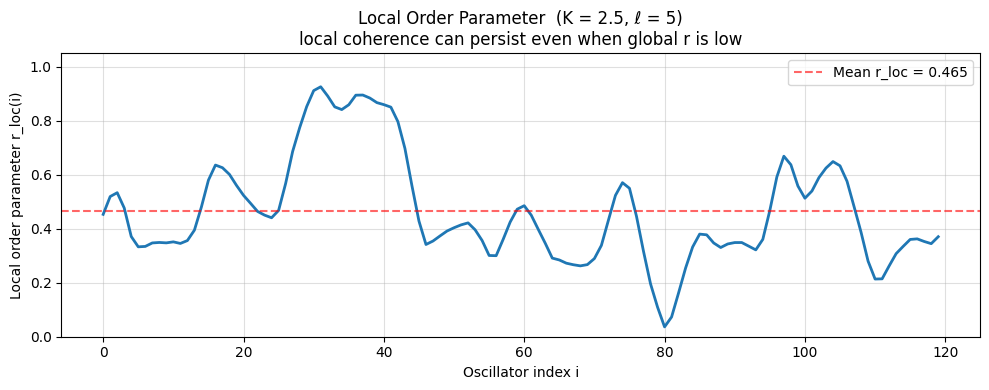

In [91]:
def local_order_parameter(theta, ell=5):
    """r_loc(i) = |mean of exp(iθ_j) over j in [i-ell, i+ell]|.
    Unlike the global r, this is sensitive to local phase coherence
    even when global r ≈ 0 (e.g. twisted states).
    """
    N = len(theta)
    r_loc = np.zeros(N)
    for i in range(N):
        neighbors = [theta[(i + k) % N] for k in range(-ell, ell + 1)]
        r_loc[i] = np.abs(np.mean(np.exp(1j * np.array(neighbors))))
    return r_loc

theta_t_end = sol.sol(t_plot[-1])
r_loc = local_order_parameter(theta_t_end, ell=5)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(r_loc, linewidth=2)
ax.axhline(y=np.mean(r_loc), color='red', linestyle='--', alpha=0.6, label=f'Mean r_loc = {np.mean(r_loc):.3f}')
ax.set_xlabel('Oscillator index i')
ax.set_ylabel('Local order parameter r_loc(i)')
ax.set_title(f'Local Order Parameter  (K = {K_sim}, ℓ = 5)\nlocal coherence can persist even when global r is low')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
print(f"Global r = {order_parameter(theta_t_end):.4f}  (snapshot at t={t_plot[-1]:.0f}; cf. time-averaged values in cell 5)")
print(f"Mean local r_loc = {np.mean(r_loc):.4f}  (snapshot at t={t_plot[-1]:.0f}; useful alongside q, q-stability, and frequency-locking diagnostics)")


### G. IC ensemble at fixed K — diagnosing IC dependence and winding sectors

Ring flow-capacity lower bound for this omega sample: K >= 3.696
(Necessary condition only — not a full branch-stability proof)
At K=1.5 and K=2.5, ongoing phase slips are expected.
K=1.5: 2/25 late-window q-stable | 2/25 q-stable + low freq spread | mean freq std = 0.1002
  Note: ring flow-capacity lower bound is K >= 3.696 (necessary, not sufficient).
  Late-window q-stable = q did not change in final 20%. q-stable + low freq spread = q stable AND freq std < 0.3 (below K_bound; not asymptotic locking).
K=2.5: 6/25 late-window q-stable | 6/25 q-stable + low freq spread | mean freq std = 0.0587
  Note: ring flow-capacity lower bound is K >= 3.696 (necessary, not sufficient).
  Late-window q-stable = q did not change in final 20%. q-stable + low freq spread = q stable AND freq std < 0.3 (below K_bound; not asymptotic locking).


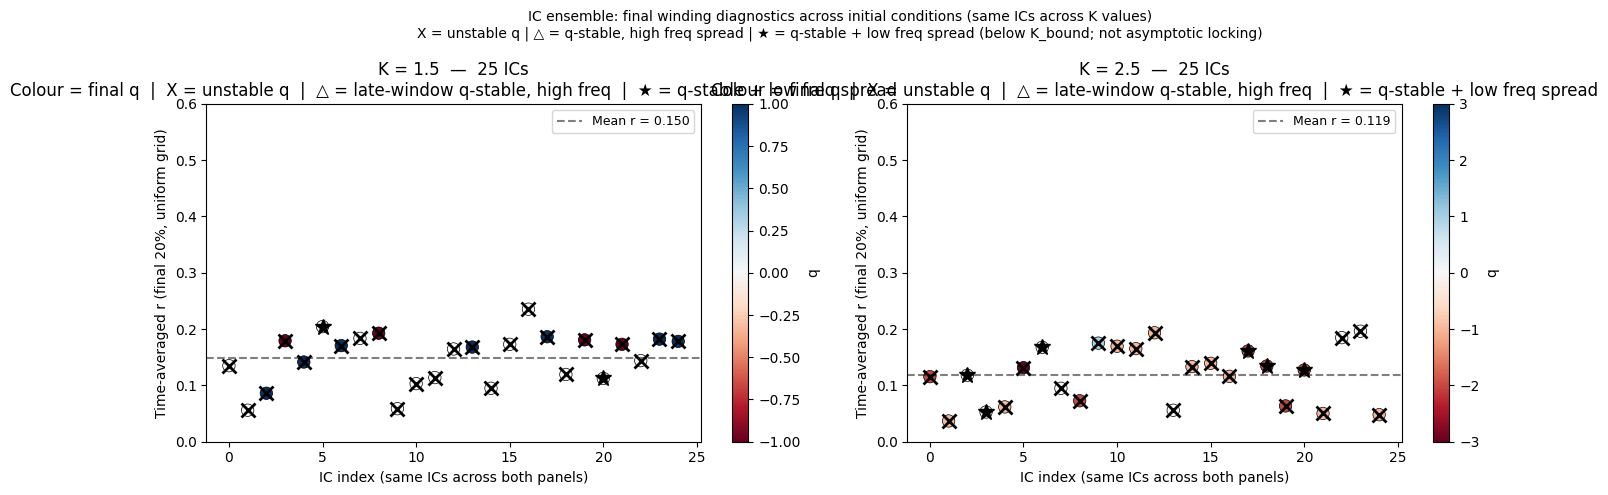

In [92]:
%matplotlib inline

# ── Diagnostic functions ──────────────────────────────────────────────────────

def q_series(theta_arr):
    """Winding number at each column of theta_arr."""
    return np.array([winding_number(theta_arr[:, j]) for j in range(theta_arr.shape[1])])

def late_q_stability(sol, frac=0.2):
    """(final_q, is_stable, q_array) over the late-time window.
    is_stable = True means q never changed in the final frac of the run.
    """
    idx = int((1 - frac) * sol.y.shape[1])
    qs = q_series(sol.y[:, idx:])
    return qs[-1], len(set(qs.tolist())) == 1, qs

def effective_frequency_std(sol, frac=0.2):
    """Std of effective frequencies over the late-time window.
    sol.y stores raw (unwrapped) phase coordinates — np.unwrap not needed.
    Low std indicates frequency locking; high std indicates ongoing drift.
    """
    idx = int((1 - frac) * sol.y.shape[1])
    theta_late = sol.y[:, idx:]  # raw coordinates, already unwrapped by the integrator
    dt = sol.t[-1] - sol.t[idx]
    omega_eff = (theta_late[:, -1] - theta_late[:, 0]) / dt
    return np.std(omega_eff)

def ring_locking_lower_bound(omega):
    """Flow-capacity lower bound for frequency locking on a nearest-neighbour ring.
    Necessary condition only — not a full branch-stability proof.
    """
    nu = omega - np.mean(omega)
    S = np.r_[0.0, np.cumsum(nu)]
    return 0.5 * (S.max() - S.min())

K_bound = ring_locking_lower_bound(omega)
print(f"Ring flow-capacity lower bound for this omega sample: K >= {K_bound:.3f}")
print(f"(Necessary condition only — not a full branch-stability proof)")
print(f"At K=1.5 and K=2.5, ongoing phase slips are expected.")

FREQ_STD_THRESHOLD = 0.3  # ≈ σ/2 where σ=0.65; below this, late-window freq dispersion is sub-disorder-scale

# ── Ensemble ──────────────────────────────────────────────────────────────────

K_test_values = [1.5, 2.5]
M = 25
rng_ens = np.random.default_rng(7)
T_EVAL_ENS = np.linspace(t_span[0], t_span[1], 1500)
theta0_ensemble = rng_ens.uniform(0, 2*np.pi, size=(M, N))  # same ICs for both K values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, K_test in zip(axes, K_test_values):
    r_ensemble, q_ensemble, q_is_stable, freq_std_list = [], [], [], []

    for th0 in theta0_ensemble:
        s = solve_ivp(kuramoto, t_span, th0, args=(omega, K_test, N),
                      method='DOP853', t_eval=T_EVAL_ENS, rtol=1e-7, atol=1e-9)
        if not s.success:
            raise RuntimeError(f"K={K_test}: {s.message}")

        # Time-averaged r over final 20% (uniform grid)
        idx = int(0.8 * len(T_EVAL_ENS))
        r_late = np.mean([order_parameter(s.y[:, j]) for j in range(idx, len(T_EVAL_ENS))])
        r_ensemble.append(r_late)

        # q stability
        q_final, is_stable, _ = late_q_stability(s)
        q_ensemble.append(q_final)
        q_is_stable.append(is_stable)

        # Frequency spread
        fstd = effective_frequency_std(s)
        freq_std_list.append(fstd)

    q_abs_max = max(abs(q) for q in q_ensemble) if q_ensemble else 1
    q_abs_max = max(q_abs_max, 1)
    scatter = ax.scatter(range(M), r_ensemble, c=q_ensemble, cmap='RdBu', s=80,
                         edgecolors='black', linewidths=0.5,
                         vmin=-q_abs_max, vmax=q_abs_max)

    # Three marker classes:
    # X = unstable q in final 20%
    # triangle = late-window q-stable but high freq spread
    # star = q-stable + low freq spread (below K_bound; not asymptotic locking)
    for j, (r, stable, fstd) in enumerate(zip(r_ensemble, q_is_stable, freq_std_list)):
        if not stable:
            ax.plot(j, r, 'kx', markersize=10, markeredgewidth=2)
        elif fstd > FREQ_STD_THRESHOLD:
            ax.plot(j, r, 'k^', markersize=8, markeredgewidth=1.5, fillstyle='none')
        else:
            ax.plot(j, r, 'k*', markersize=12, markeredgewidth=1)

    ax.axhline(np.mean(r_ensemble), color='black', linestyle='--', alpha=0.5,
               label=f'Mean r = {np.mean(r_ensemble):.3f}')
    ax.set_xlabel('IC index (same ICs across both panels)')
    ax.set_ylabel('Time-averaged r (final 20%, uniform grid)')
    ax.set_title(f'K = {K_test}  —  {M} ICs\nColour = final q  |  X = unstable q  |  △ = late-window q-stable, high freq  |  ★ = q-stable + low freq spread')
    ax.set_ylim(0, 0.6)
    ax.legend(fontsize=9)
    plt.colorbar(scatter, ax=ax, label='q')

    stable_count = sum(q_is_stable)
    q_stable_low_freq = sum(1 for s, f in zip(q_is_stable, freq_std_list) if s and f <= FREQ_STD_THRESHOLD)
    mean_freq_std = np.mean(freq_std_list)
    print(f"K={K_test}: {stable_count}/{M} late-window q-stable | {q_stable_low_freq}/{M} q-stable + low freq spread | mean freq std = {mean_freq_std:.4f}")
    print(f"  Note: ring flow-capacity lower bound is K >= {K_bound:.3f} (necessary, not sufficient).")
    print(f"  Late-window q-stable = q did not change in final 20%. q-stable + low freq spread = q stable AND freq std < {FREQ_STD_THRESHOLD} (below K_bound; not asymptotic locking).")

plt.suptitle('IC ensemble: final winding diagnostics across initial conditions (same ICs across K values)\n'
             'X = unstable q | △ = q-stable, high freq spread | ★ = q-stable + low freq spread (below K_bound; not asymptotic locking)',
             fontsize=10)
plt.tight_layout()


### H. Long-run check — r(t) and q(t) over T=400

This is a stress test, not a convergence proof. Because K=1.5 and K=2.5 are below the
ring flow-capacity lower bound for this omega sample, q(t) can still change late in
the trajectory. The plot checks whether the chosen averaging window is descriptive
or genuinely settled for the sampled IC. Late q changes in the output indicate ongoing
phase slips — expected at these K values.


K=1.5: late-trajectory mean r = 0.1137, final q = 0, late q changes after 80% = 8
K=2.5: late-trajectory mean r = 0.1018, final q = -2, late q changes after 80% = 2


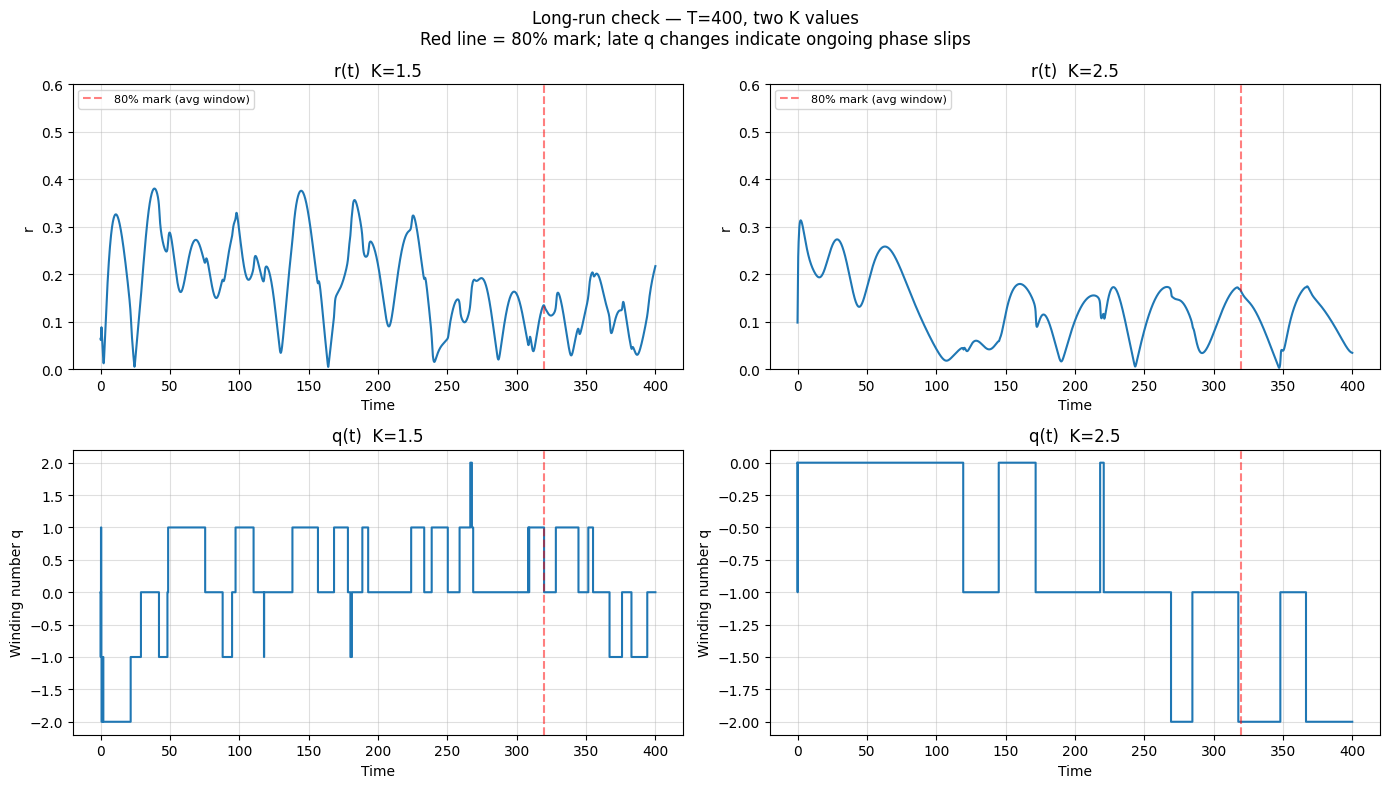

In [93]:
%matplotlib inline
# Long-run stress test: integrate to T=400 at K=1.5 and K=2.5
# and plot r(t) + q(t). Below K_bound, q keeps slipping — that is expected, not a failure.

T_long = 400
t_long = np.linspace(0, T_long, 4000)
rng_conv = np.random.default_rng(123)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col, K_test in enumerate([1.5, 2.5]):
    th0 = rng_conv.uniform(0, 2*np.pi, N)
    sol_long = solve_ivp(kuramoto, (0, T_long), th0, args=(omega, K_test, N),
                         method='DOP853', dense_output=True, rtol=1e-7, atol=1e-9)
    if not sol_long.success:
        raise RuntimeError(f"K={K_test}: {sol_long.message}")
    t_eval = np.linspace(0, T_long, 4000)
    r_long = [order_parameter(sol_long.sol(t)) for t in t_eval]
    q_long = [winding_number(sol_long.sol(t)) for t in t_eval]

    # r(t)
    axes[0, col].plot(t_eval, r_long, linewidth=1.5)
    axes[0, col].axvline(x=0.8*T_long, color='red', linestyle='--', alpha=0.5, label='80% mark (avg window)')
    axes[0, col].set_title(f'r(t)  K={K_test}')
    axes[0, col].set_xlabel('Time')
    axes[0, col].set_ylabel('r')
    axes[0, col].set_ylim(0, 0.6)
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.4)

    # q(t)
    axes[1, col].step(t_eval, q_long, where='mid', linewidth=1.5)
    axes[1, col].axvline(x=0.8*T_long, color='red', linestyle='--', alpha=0.5)
    axes[1, col].set_title(f'q(t)  K={K_test}')
    axes[1, col].set_xlabel('Time')
    axes[1, col].set_ylabel('Winding number q')
    axes[1, col].grid(True, alpha=0.4)

    late_r = np.mean(r_long[int(0.8*len(r_long)):])
    late_q_arr = np.array(q_long[int(0.8*len(q_long)):])
    late_q_changes = np.count_nonzero(np.diff(late_q_arr))
    print(f"K={K_test}: late-trajectory mean r = {late_r:.4f}, final q = {q_long[-1]}, late q changes after 80% = {late_q_changes}")

plt.suptitle('Long-run check — T=400, two K values\nRed line = 80% mark; late q changes indicate ongoing phase slips', fontsize=12)
plt.tight_layout()


## 3. Play with it

Drag the sliders. Each change re-seeds, re-integrates, and re-renders the phase-evolution heatmap and the final ring configuration.

- **K** — coupling strength. Mean-field intuitions don't apply here; r stays low across the whole sweep. The interesting structure is winding-sector geometry, local coherence, and phase slips.
- **N** — number of oscillators on the ring.
- **seed** — randomness for natural frequencies and initial phases.

In [94]:
@interact(
    K=FloatSlider(min=0.0, max=4.0, step=0.1, value=2.5, description='K'),
    N=IntSlider(min=20, max=200, step=10, value=120, description='N'),
    seed=IntSlider(min=0, max=100, step=1, value=42, description='seed'),
)
def explore(K, N, seed):
    rng_w = np.random.default_rng(seed)
    omega = rng_w.normal(0.0, 0.65, N)
    theta0 = rng_w.uniform(0, 2*np.pi, N)
    t_plot = np.linspace(0, 80, 600)
    sol = solve_ivp(kuramoto, (0, 80), theta0, args=(omega, K, N),
                    method='DOP853', t_eval=t_plot, rtol=1e-7, atol=1e-9)
    if not sol.success:
        raise RuntimeError(sol.message)
    theta_sol = sol.y
    phases_wrapped = theta_sol % (2 * np.pi)
    theta_final = sol.y[:, -1]

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
    pc = axL.pcolormesh(t_plot, np.arange(N), phases_wrapped, cmap='twilight_shifted', shading='auto')
    fig.colorbar(pc, ax=axL, label='Phase (mod 2π)')
    axL.set_xlabel('Time')
    axL.set_ylabel('Oscillator index')
    axL.set_title(f'Phase evolution  (K={K:.2f}, N={N}, seed={seed})')

    phase_final = theta_final % (2 * np.pi)
    x = np.cos(phase_final)
    y = np.sin(phase_final)
    axR.scatter(x, y, c=phase_final, cmap='twilight_shifted', vmin=0, vmax=2*np.pi, s=60, edgecolor='black', linewidth=0.5)
    for i in range(N):
        axR.plot([x[i], x[(i+1) % N]], [y[i], y[(i+1) % N]], 'k-', alpha=0.25, linewidth=1)
    axR.set_title(f'Final ring  (r = {order_parameter(theta_final):.3f})')
    axR.axis('equal')
    axR.set_xticks([])
    axR.set_yticks([])
    plt.tight_layout()
    plt.show()


interactive(children=(FloatSlider(value=2.5, description='K', max=4.0), IntSlider(value=120, description='N', …